# 1 Exploratory Data Analysis
This notebooks provides a comprehensive exploratory and data analysis of our dataset in order to understand our data and elaborate a proper preprocessing and feature engineering work being aware of the shape and main characteristics of our data.

## 1.1 Initialization and Data Loading
First, we start by importing all necessary libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})
warnings.filterwarnings('ignore')

np.random.seed(42)

We now can import the dataset, and take an initial look:

In [2]:
df = pd.read_csv('../data/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


## 1.2 Data Cleaning
We know from the documentation that `url` and `timedelta` variables are non-predictive metadata, as the url is simply the direction of the article, while the timedelta represents the days between the article publication and data acquisition. For this reason, they should be removed:

In [3]:
df_clean = df.drop(columns=['url', 'timedelta'])

We also verify missing values and duplicates:

In [4]:
missing_values = df_clean.isnull().sum()
print("Columns with missing values:", missing_values[missing_values > 0].sum())

duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Dataset shape after dropping duplicates: {df_clean.shape}")

Columns with missing values: 0
Duplicate rows: 0


We can see that neither missing values nor duplicates rows are present, so we do not need to take any actions to fix it.

## 1.3 Target Variable Analysis
In this section, we perform an analysis on our target variable `shares`. We start by analyzing the original distribution of the variable in a histogram:

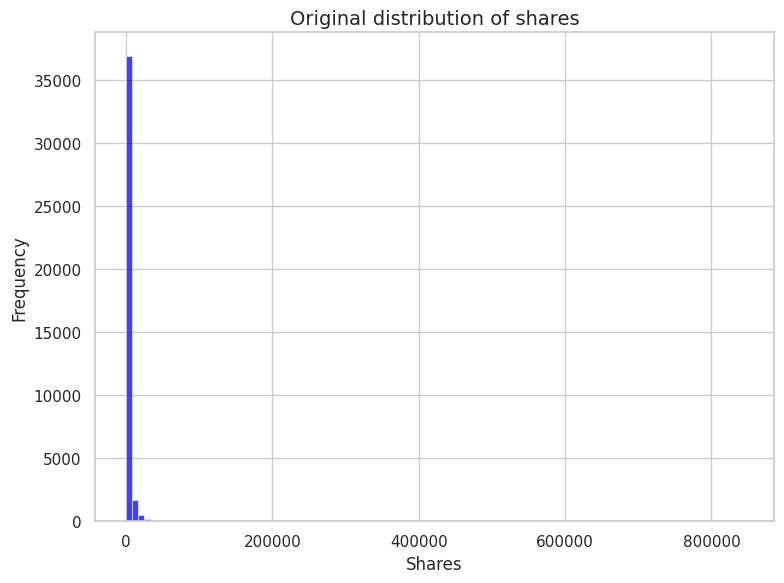

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.histplot(df_clean['shares'], bins=100, ax=ax, color='blue', kde=False)
ax.set_title('Original distribution of shares')
ax.set_xlabel('Shares')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

We can see that the target variable is highly skewed. This represents a problem for the models we will train, specially for Linear and regularized models, which struggle with skewed target variables.

To solve this issue, we can apply a log transformation to stabilize the variance and obtain a distribution more similar to a normal one:

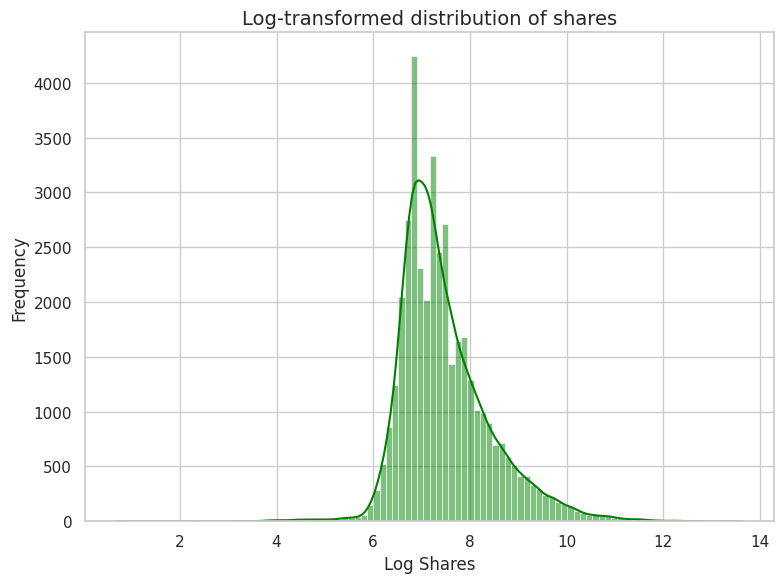

In [6]:
df_clean['log_shares'] = np.log1p(df_clean['shares'])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(df_clean['log_shares'], bins=100, ax=ax, color='green', kde=True)
ax.set_title('Log-transformed distribution of shares')
ax.set_xlabel('Log Shares')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

As we can see, the log transformation successfully transformed the distribution to a more normal one. For this reason, during the modelling tasks, specially with linear models, we will train the model predicting the log-transformed `shares` to stabilize the variance, and then transform predictions back using the exponential function when calculating metrics like MAE or RMSE.

## 1.4 Continuous Features Analysis
We now analyze the distribution of our numerical variables. As we have more than 40, performing an individual analysis of all of them would affect the clarity of the notebook, so we show the analysis just for a relevant subset of the features:

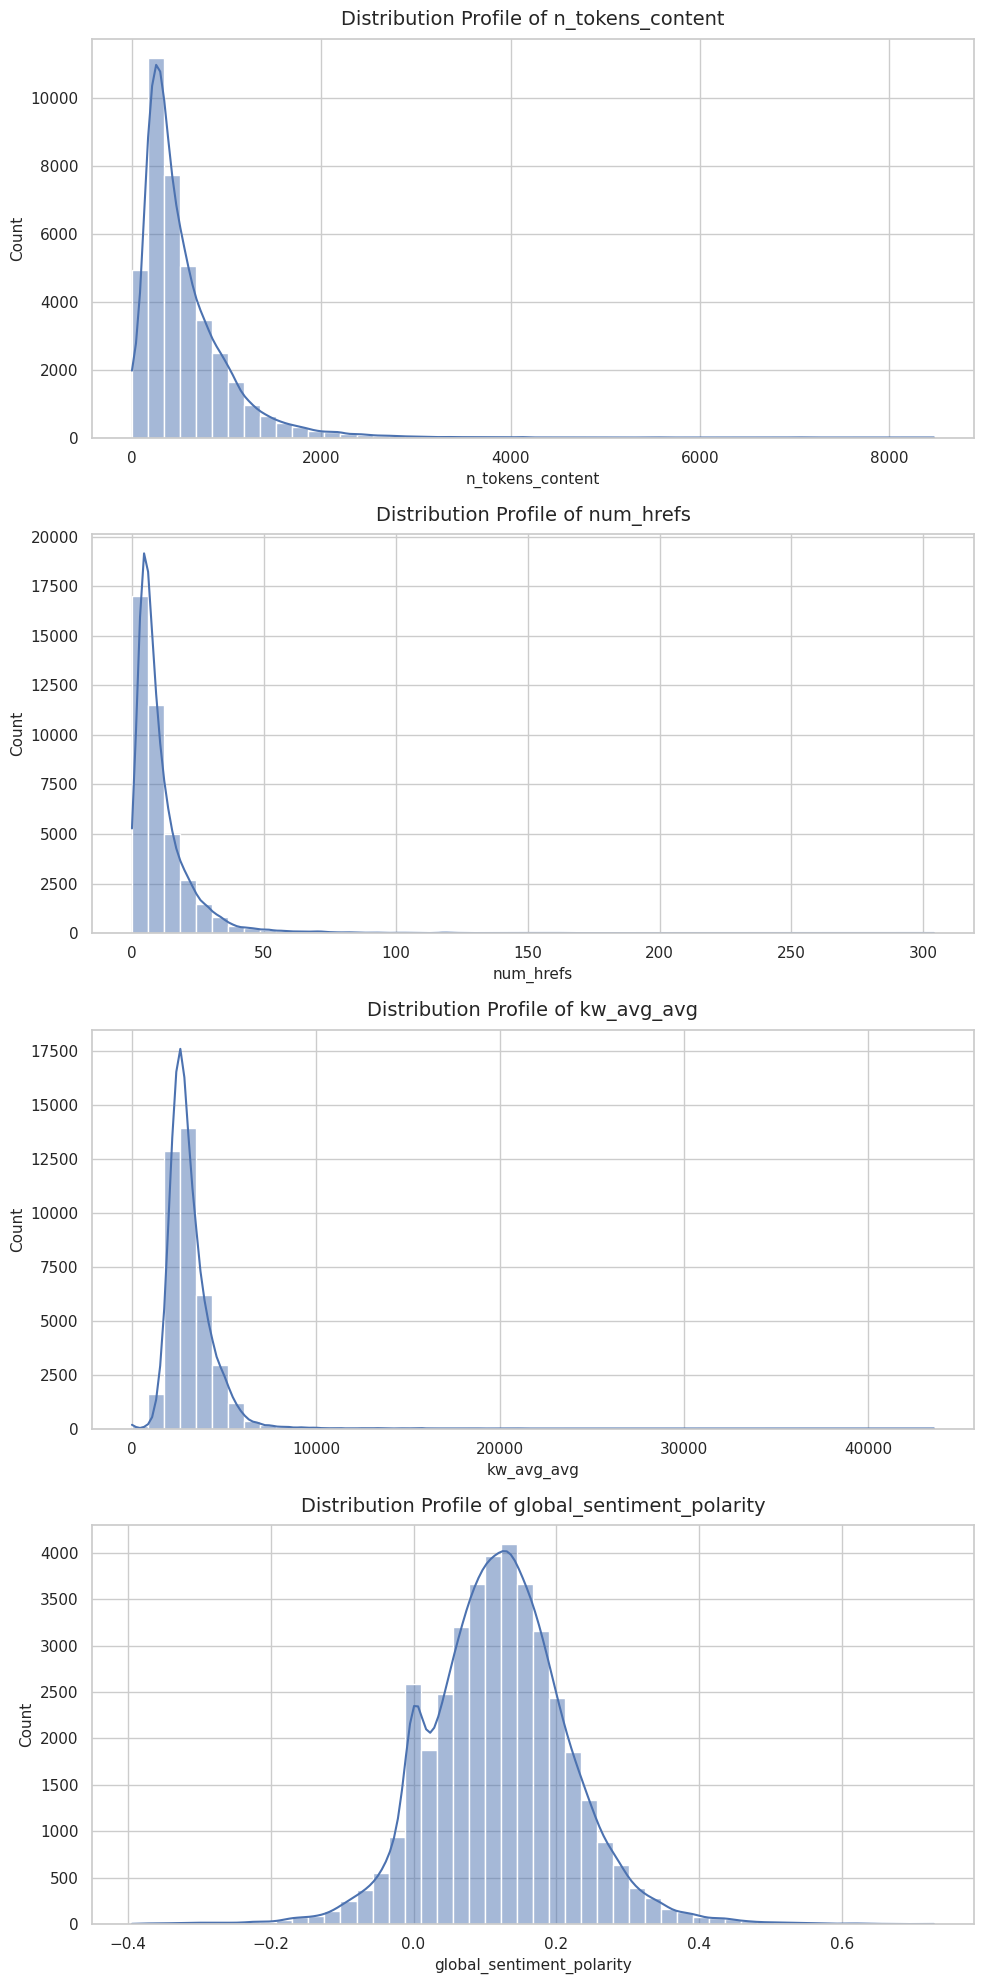

In [7]:
representative_features = [
    'n_tokens_content',          
    'num_hrefs',                 
    'kw_avg_avg',                 
    'global_sentiment_polarity'   
]

fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for idx, col in enumerate(representative_features):
    sns.histplot(
        data=df_clean, x=col, kde=True, ax=axes[idx], 
        color='#4C72B0', bins=50, edgecolor='white'
    )
    axes[idx].set_title(f'Distribution Profile of {col}', fontsize=14, pad=10)
    axes[idx].set_xlabel(col, fontsize=11)
    axes[idx].set_ylabel('Count', fontsize=11)

plt.tight_layout()
plt.show()

The histograms show two completely different types of data structures within the dataset. The first three features (`n_tokens_content`, `num_hrefs`, and `kw_avg_avg`) show severe right-skewed distributions. The majority of articles have low values, but a long tail of articles have rare, high values. In contrast, `global_sentiment_polarity` shows a highly symmetric Gaussian (normal) distribution centered above 0.0, meaning most articles maintain a neutral tone.

We now analyze the Boxplots of these continuous variables to clearly visualize the outliers:

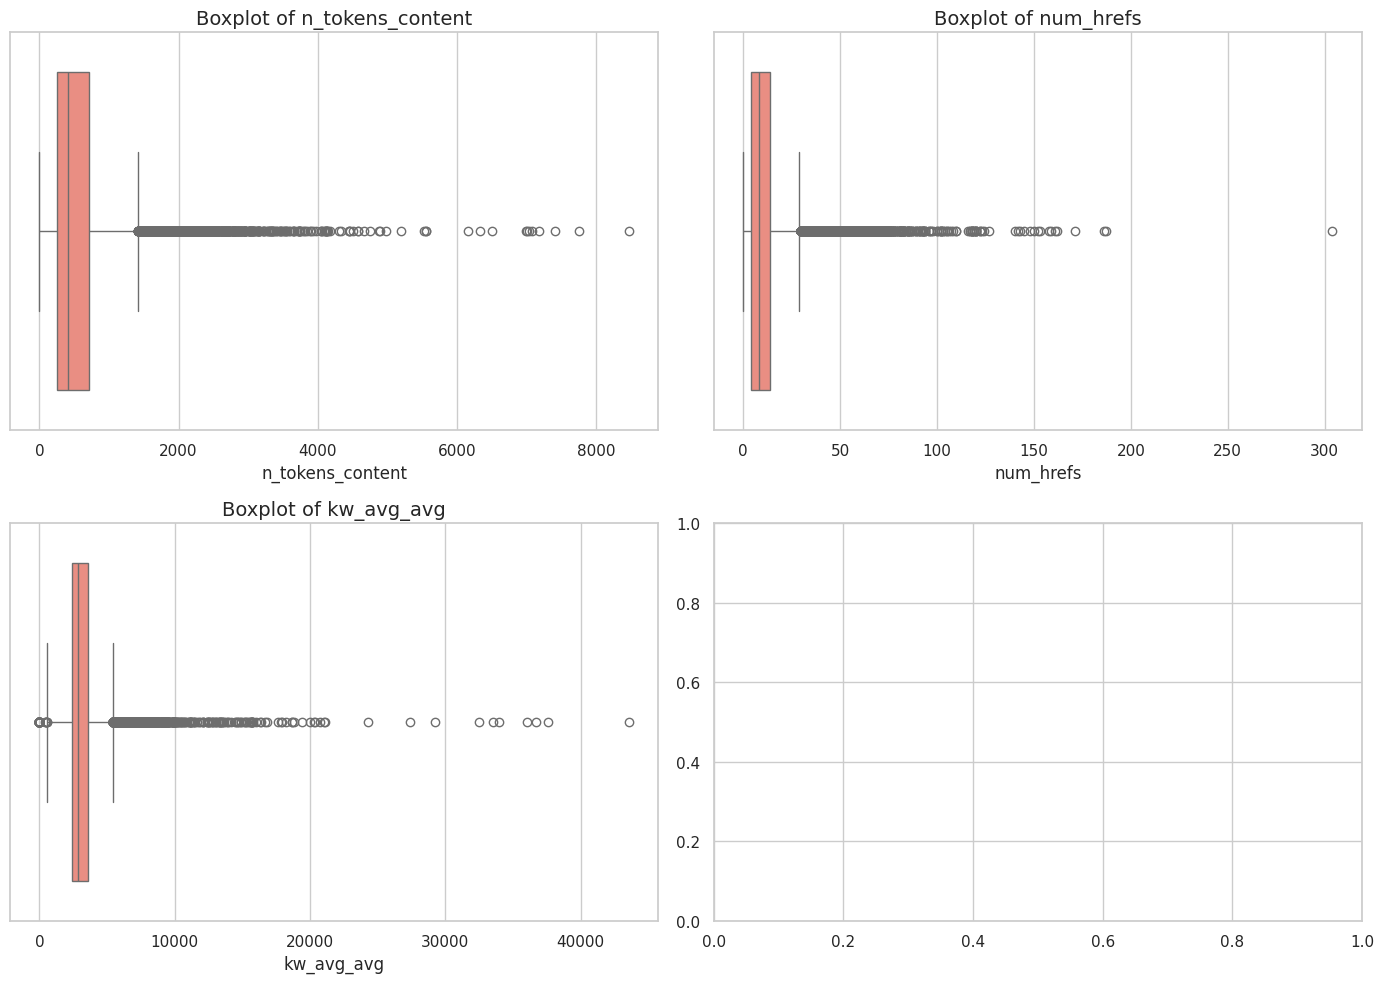

In [8]:
features_to_check = ['n_tokens_content', 'num_hrefs', 'kw_avg_avg']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_check):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

The Boxplots show severe righ-skewed distributions across all four variables, characterized by highly compressed boxes (interquantil ranges) placed at the left axis and wirh an long tail of outliers. For example, while typical article length (`n_tokens_content`) or keyword average (`kw_avg_avg`) stays concentrated within a small region of values, a group of extreme data points are placed far away leading to this long tail.

These outliers present problems for several models, such as distance-based or linear models (PCA, K-Means, linear models, and SVM). To effectively mitigate this problem, we will need to apply some outlier-detection technique and remove them.

 ## 1.5 Categorical Features Analysis
 Now we move to the analysis of the categorical variables: data channel and weekday. We start by analyzing the number of articles per channel and the distribution of log shares per each channel.

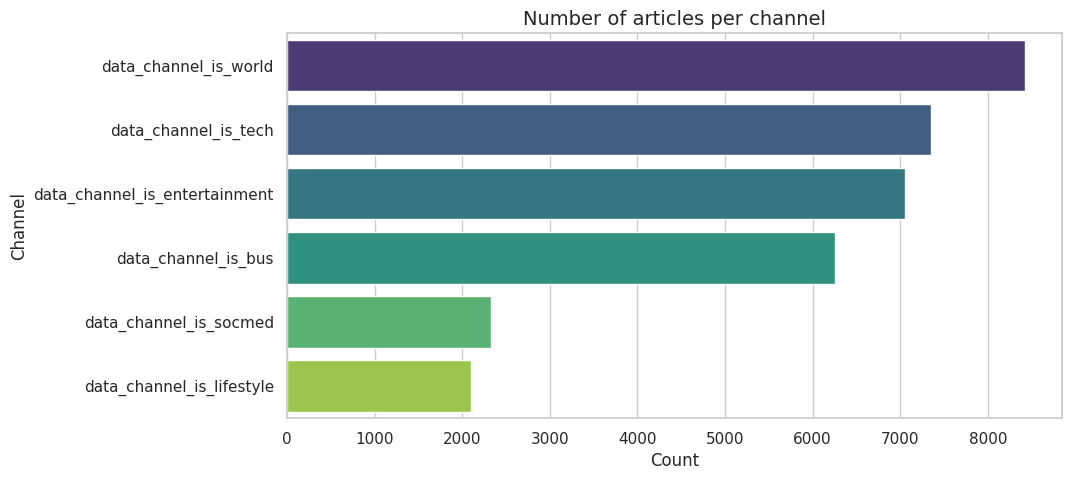

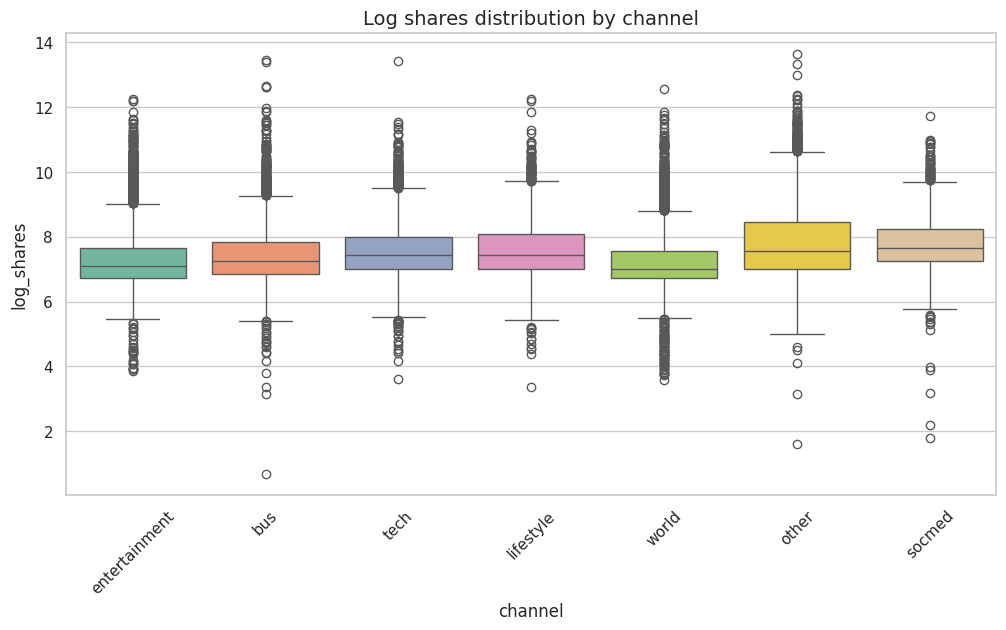

In [9]:
channel_cols = [col for col in df_clean.columns if 'data_channel_is' in col]
channel_counts = df_clean[channel_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=channel_counts.values, y=channel_counts.index, palette='viridis')
plt.title('Number of articles per channel')
plt.xlabel('Count')
plt.ylabel('Channel')
plt.show()

df_clean['channel'] = df_clean[channel_cols].idxmax(axis=1).str.replace('data_channel_is_', '')
df_clean.loc[df_clean[channel_cols].sum(axis=1) == 0, 'channel'] = 'other'

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='channel', y='log_shares', palette='Set2')
plt.title('Log shares distribution by channel')
plt.xticks(rotation=45)
plt.show()

df_clean.drop(columns=['channel'], inplace=True)

The data shows a clear imbalance in article publication volume across different channels. News regarding world topics, tech, and entertainment dominates the number of publishing articles, while social media and lifestyle articles are produced far less frequently. 

Despite the variance in publications volume, the median performance, captured by the horizontal lines within the boxes, remain highly similar across all seven groups. This uniform distribution indicates that only for belonging to an specific channel does not guarantee more popularity.

Now, we analyze the categorical variables `weekday` to see how it affects the popularity:

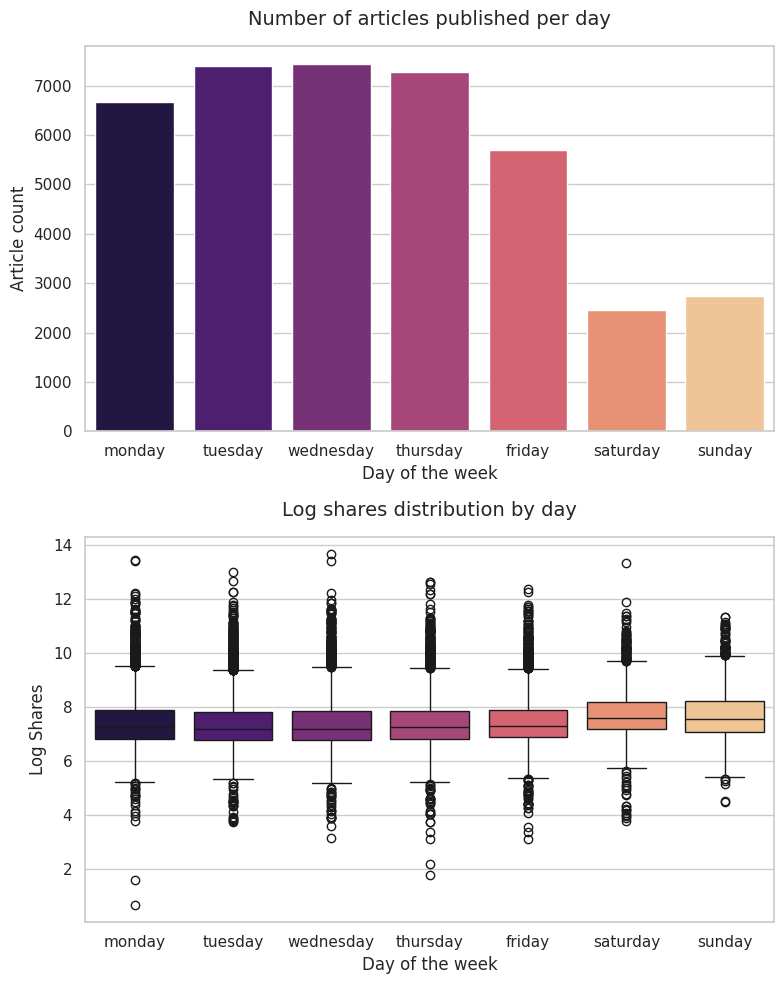

In [10]:
weekday_cols = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 
    'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday'
]
df_clean['weekday'] = df_clean[weekday_cols].idxmax(axis=1).str.replace('weekday_is_', '')
day_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

fig, axes = plt.subplots(2, 1, figsize=(8, 10))
sns.countplot(
    data=df_clean, x='weekday', order=day_order, ax=axes[0], palette='magma'
)
axes[0].set_title('Number of articles published per day', pad=15)
axes[0].set_xlabel('Day of the week')
axes[0].set_ylabel('Article count')

sns.boxplot(
    data=df_clean, x='weekday', y='log_shares', order=day_order, ax=axes[1], palette='magma'
)
axes[1].set_title('Log shares distribution by day', pad=15)
axes[1].set_xlabel('Day of the week')
axes[1].set_ylabel('Log Shares')

plt.tight_layout()
plt.show()

df_clean.drop(columns=['weekday'], inplace=True)

The top plot shows that the days with most publicated papers are from Tuesday to Thursday, dropping slightly on Monday and Friday, before dropping significantly on the weekend. However, the bottom plot shows a reversal behavior, the median log shares for weekend are clearly higher than any weekday. 

## 1.6 Multicollinearity and Correlation
Linear models (Ridge/Lasso)  assume independence between features. We need to identify highly correlated features (multicollinearity) and features that correlate well with our target.  

We first analyze the correlation between the numerical features. We use Spearman correlation as it is robust to outliers and skewed distributions:

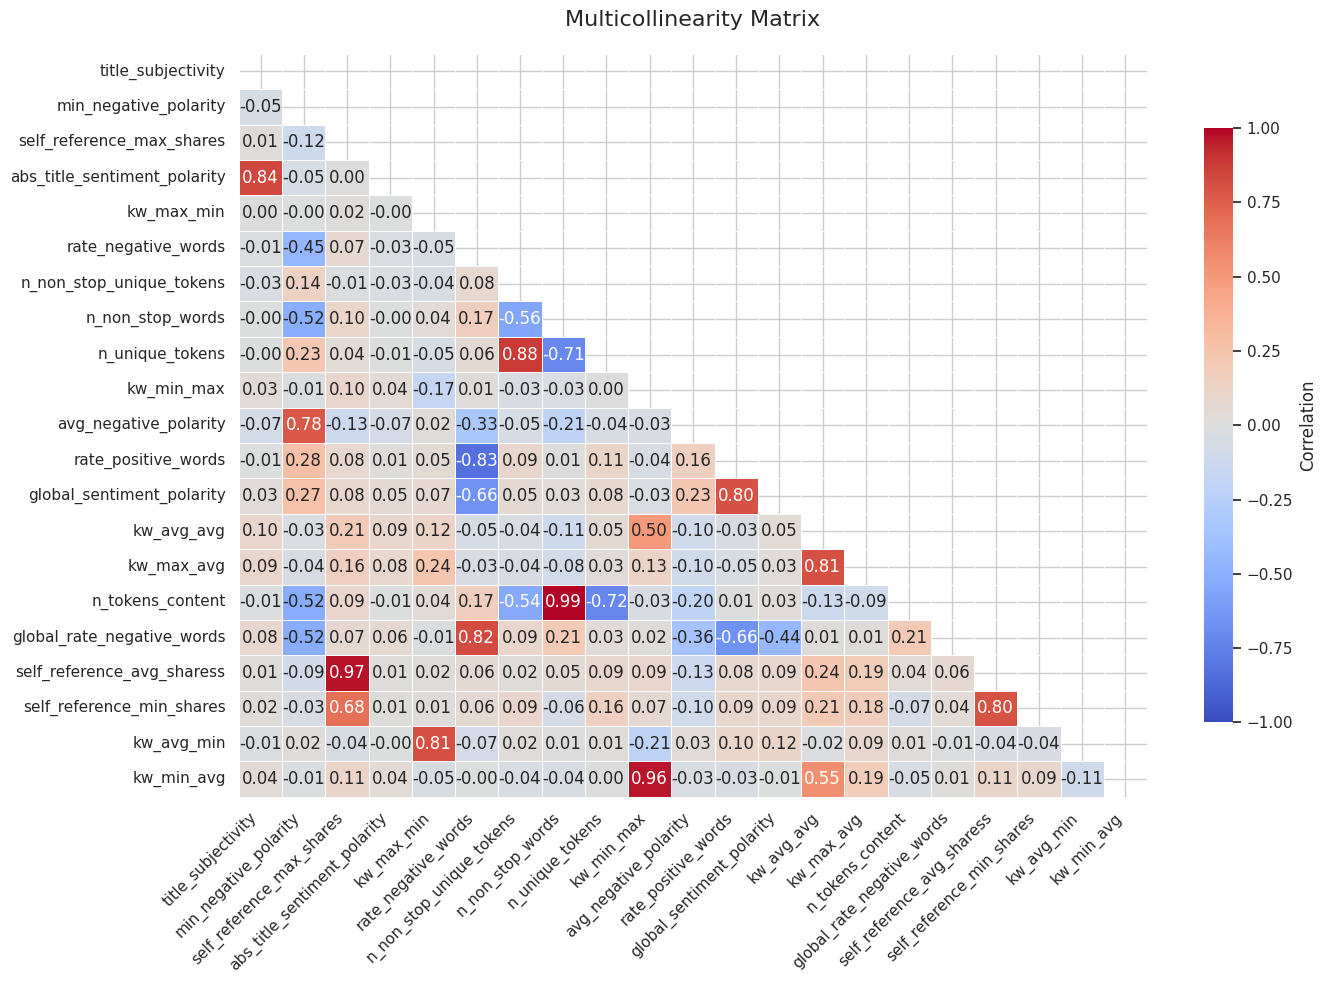

In [11]:
corr_matrix = df_clean.drop(columns=['shares']).corr(method='spearman')
target_corr = corr_matrix['log_shares'].drop('log_shares').sort_values(ascending=False)

# Select the top 10 positive and top 10 negative correlated features
top_positive = target_corr.head(10)
top_negative = target_corr.tail(10)
top_target_corrs = pd.concat([top_positive, top_negative]).sort_values(ascending=False)

collinearity_threshold = 0.75
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

collinear_features = set()
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if abs(upper_tri.loc[idx, col]) > collinearity_threshold:
            collinear_features.update([idx, col])

# Filter matrix to show only the features with high multicollinearity
collinear_matrix = corr_matrix.loc[list(collinear_features), list(collinear_features)]

plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(collinear_matrix, dtype=bool))

sns.heatmap(
    collinear_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title('Multicollinearity Matrix', pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The heatmap shows multiple clusters of severe multicollinearity where pairs of variables are almost identical. Specifically, `n_non_stop_words` has a nearly perfect correlation (0.99) with `n_tokens_content`, and `kw_min_max` with `kw_min_avg` (0.96). We also see strong keyword metric pairs like `kw_max_avg` and `self_reference_avg_sharess` highly correlated (0.97). On the negative side, strong logical negative correlations appear, such as `rate_positive_words` against `rate_negative_words` (-0.83).

These significant correlations pose a problem for linear optimization algorithms such as OLS. This justifies the use of regularization techiques such as Ridge or Lasso Regression. 

We now analyze the correlation of our features with the target variable `log_shares`:

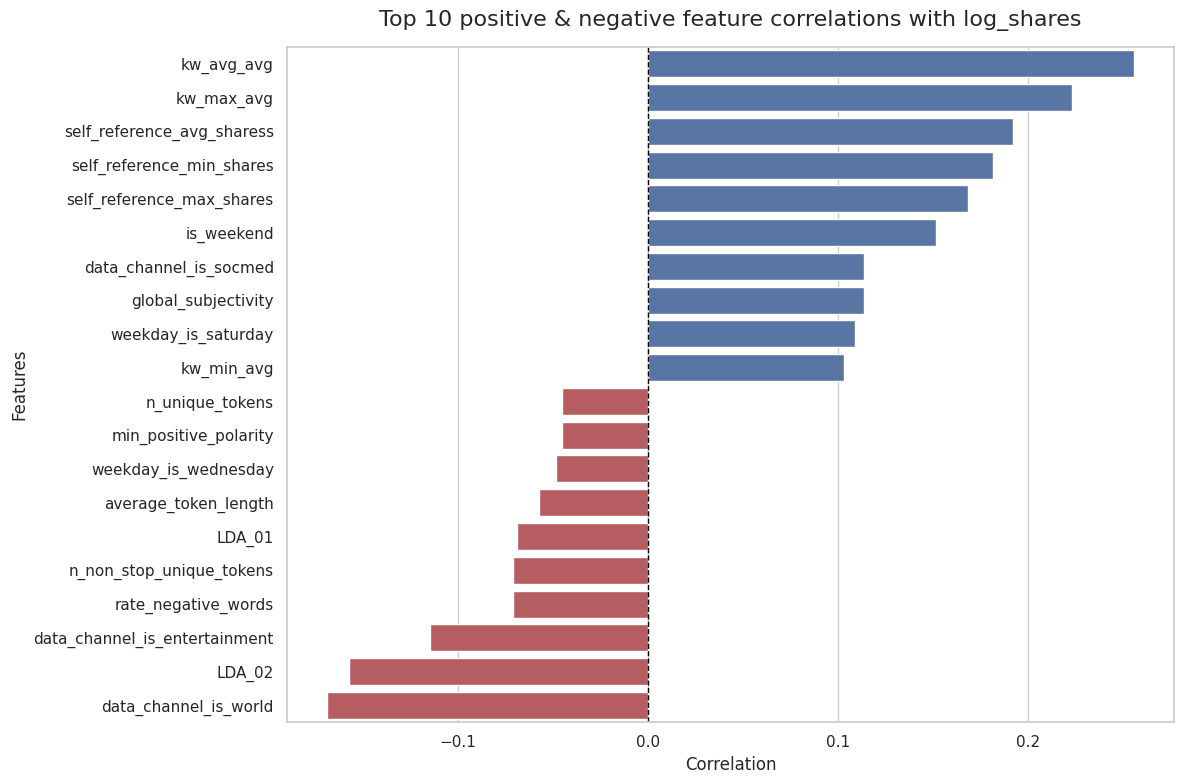

In [12]:
plt.figure(figsize=(12, 8))

colors = ['#4C72B0' if val > 0 else '#C44E52' for val in top_target_corrs.values]

sns.barplot(
    x=top_target_corrs.values, 
    y=top_target_corrs.index, 
    palette=colors
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Top 10 positive & negative feature correlations with log_shares', pad=15, fontsize=16)
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The plot shows that keyword performance and self-referencing are the strongest positive features of article popularity. Specifically, `kw_avg_avg` (avg popularity of the article's keywords) and `kv_max_avg` show the highest positive correlation with the target variable. Articles that link to other highly shared articles (`self_reference_avg_sharess`) or are published over the weekend also show a strong positive relationship. 

On the other hand, publishing channel types and topic themes are the strongest negatively correlated variables with the article shares. Belonging to `data_channel_is_world` channel shows the strongest negative correlation, closely folllowed by the articles aligned with the `LDA_02` topic or the `entertainment` channel. In addition, text metrics like `n_unique_tokens` show a negative correlation, indicating complex vocabulary might leads to less popularity.